# Task 1: Computer Screen Detection using Hough Lines

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

## Objective
Detect monitor boundaries in a computer-lab image using Canny edges and the probabilistic Hough line transformation. Near-horizontal and near-vertical line segments are retained, and rectangular screen candidates are extracted from contours.

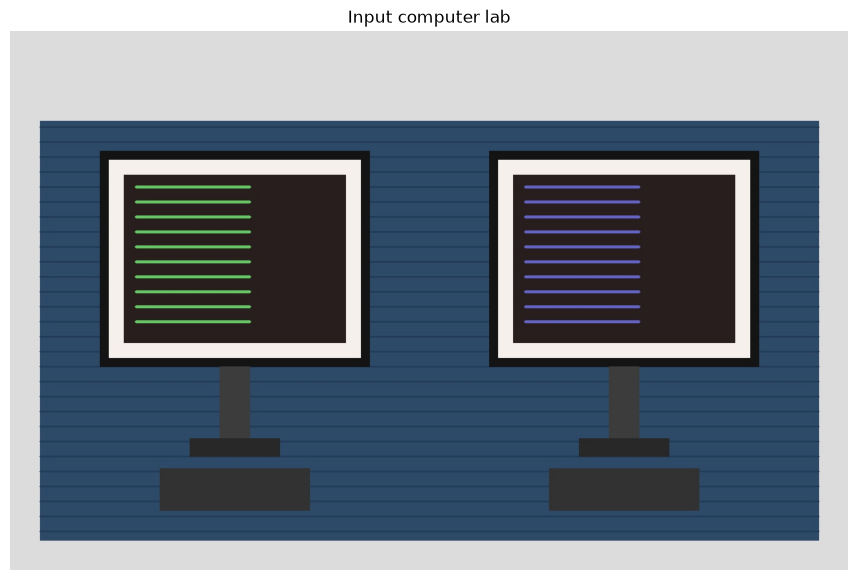

In [13]:
IMAGE_PATH = 'computer_lab.jpg'   
img = cv.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Add a computer-lab image at: {IMAGE_PATH}")
show(img, 'Input computer lab')

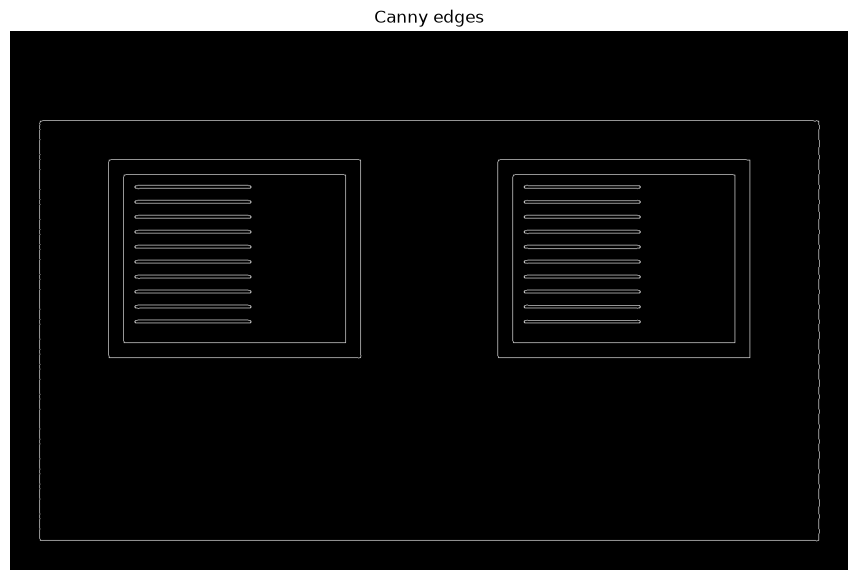

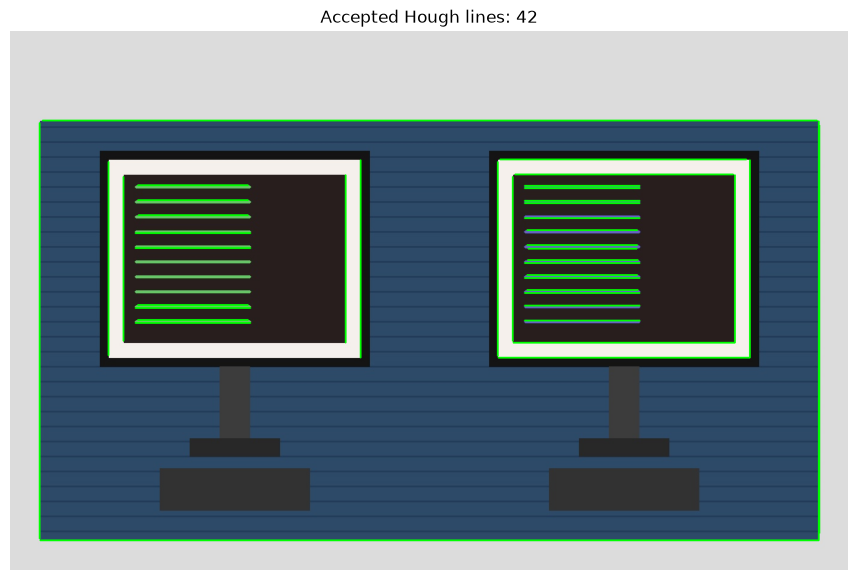

Accepted Hough lines: 42


In [14]:
# ============================================================
# Edge Detection + Hough Line Detection
# ============================================================

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(
    gray,
    (5, 5),
    1.2
)

edges = cv.Canny(
    blur,
    60,
    160
)

# ------------------------------------------------------------
# Detect line segments
# ------------------------------------------------------------

lines = cv.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=65,
    minLineLength=50,
    maxLineGap=18
)

line_view = img.copy()
accepted = []

H, W = gray.shape

# Ignore lines that lie directly on the image boundary
border_margin = 15

if lines is not None:

    # Make the output safe regardless of whether OpenCV
    # returns (N, 1, 4) or (N, 4)
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        angle = abs(
            np.degrees(
                np.arctan2(
                    y2 - y1,
                    x2 - x1
                )
            )
        )

        # ----------------------------------------------------
        # Reject image-border lines
        # ----------------------------------------------------

        near_left = max(x1, x2) <= border_margin
        near_right = min(x1, x2) >= W - border_margin
        near_top = max(y1, y2) <= border_margin
        near_bottom = min(y1, y2) >= H - border_margin

        if near_left or near_right or near_top or near_bottom:
            continue

        # ----------------------------------------------------
        # Keep horizontal / vertical lines
        # ----------------------------------------------------

        if angle < 12 or angle > 78:

            accepted.append(
                (x1, y1, x2, y2)
            )

            cv.line(
                line_view,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )


# ------------------------------------------------------------
# Display Hough result
# ------------------------------------------------------------

show(
    edges,
    "Canny edges"
)

show(
    line_view,
    f"Accepted Hough lines: {len(accepted)}"
)

print("Accepted Hough lines:", len(accepted))


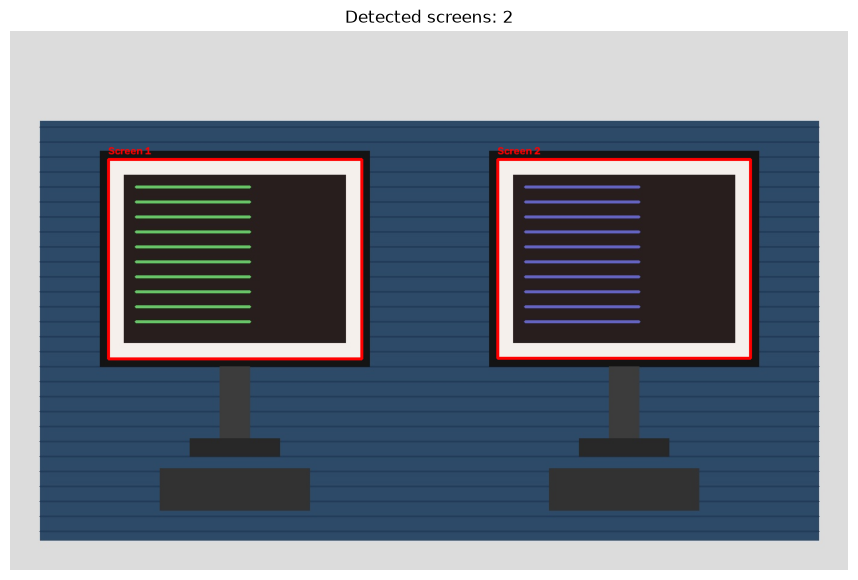

Screen count: 2
Screen candidates: [(164, 214, 423, 333), (814, 214, 422, 332)]


In [15]:
# ============================================================
# Convert Edge Evidence into Monitor Candidates
# ============================================================

# ------------------------------------------------------------
# Close small gaps in the edges
# ------------------------------------------------------------

kernel = np.ones(
    (5, 5),
    np.uint8
)

closed = cv.morphologyEx(
    edges,
    cv.MORPH_CLOSE,
    kernel,
    iterations=1
)

# ------------------------------------------------------------
# RETR_LIST retrieves inner contours as well as outer contours.
# This is important because RETR_EXTERNAL can select the
# large outer image boundary instead of the monitor.
# ------------------------------------------------------------

contours, _ = cv.findContours(
    closed,
    cv.RETR_LIST,
    cv.CHAIN_APPROX_SIMPLE
)

result = img.copy()
screens = []

H, W = gray.shape
image_area = H * W


# ============================================================
# Candidate filtering parameters
# ============================================================

min_area_ratio = 0.025
max_area_ratio = 0.25

min_width = 100
min_height = 80

min_aspect = 1.15
max_aspect = 2.0


# ============================================================
# Examine every contour
# ============================================================

for c in contours:

    x, y, w, h = cv.boundingRect(c)

    area = w * h

    area_ratio = (
        area / float(image_area)
    )

    aspect = (
        w / float(max(h, 1))
    )

    # --------------------------------------------------------
    # 1. Reject small objects
    # --------------------------------------------------------

    if w < min_width or h < min_height:
        continue

    # --------------------------------------------------------
    # 2. Reject objects that are too small or too large
    #
    # This helps remove:
    # - tiny objects
    # - large background panels
    # - giant image-boundary regions
    # --------------------------------------------------------

    if not (
        min_area_ratio
        <= area_ratio
        <= max_area_ratio
    ):
        continue

    # --------------------------------------------------------
    # 3. Require monitor-like landscape aspect ratio
    # --------------------------------------------------------

    if not (
        min_aspect
        <= aspect
        <= max_aspect
    ):
        continue

    # --------------------------------------------------------
    # 4. Require approximately rectangular contour
    # --------------------------------------------------------

    perimeter = cv.arcLength(
        c,
        True
    )

    approx = cv.approxPolyDP(
        c,
        0.02 * perimeter,
        True
    )

    # A monitor should have approximately four corners.
    if len(approx) < 4 or len(approx) > 6:
        continue

    # --------------------------------------------------------
    # 5. Reject candidates touching the image border
    # --------------------------------------------------------

    border_margin = 15

    if (
        x <= border_margin
        or y <= border_margin
        or x + w >= W - border_margin
        or y + h >= H - border_margin
    ):
        continue

    # --------------------------------------------------------
    # Accept candidate
    # --------------------------------------------------------

    screens.append(
        (x, y, w, h)
    )


# ============================================================
# Remove duplicate / nested rectangles
# ============================================================

def iou(rect1, rect2):

    x1, y1, w1, h1 = rect1
    x2, y2, w2, h2 = rect2

    xa = max(x1, x2)
    ya = max(y1, y2)

    xb = min(
        x1 + w1,
        x2 + w2
    )

    yb = min(
        y1 + h1,
        y2 + h2
    )

    if xb <= xa or yb <= ya:
        return 0.0

    intersection = (
        (xb - xa)
        * (yb - ya)
    )

    area1 = w1 * h1
    area2 = w2 * h2

    union = (
        area1
        + area2
        - intersection
    )

    return intersection / float(
        max(union, 1)
    )


# ------------------------------------------------------------
# Sort largest rectangles first
# ------------------------------------------------------------

screens = sorted(
    screens,
    key=lambda r: r[2] * r[3],
    reverse=True
)

unique_screens = []


# ------------------------------------------------------------
# Remove overlapping / nested candidates
# ------------------------------------------------------------

for candidate in screens:

    duplicate = False

    cx, cy, cw, ch = candidate

    candidate_center = (
        cx + cw / 2,
        cy + ch / 2
    )

    for existing in unique_screens:

        ex, ey, ew, eh = existing

        existing_center = (
            ex + ew / 2,
            ey + eh / 2
        )

        # IoU detects nearly identical rectangles
        overlap = iou(
            candidate,
            existing
        )

        # Center-distance detects nested screen/frame
        # contours that have nearly the same center.
        center_distance = np.hypot(
            candidate_center[0]
            - existing_center[0],

            candidate_center[1]
            - existing_center[1]
        )

        if (
            overlap > 0.45
            or center_distance < 30
        ):
            duplicate = True
            break

    if not duplicate:
        unique_screens.append(
            candidate
        )


screens = unique_screens


# ============================================================
# Sort screens left-to-right
# ============================================================

screens = sorted(
    screens,
    key=lambda r: r[0]
)


# ============================================================
# Draw detected screens
# ============================================================

for i, (x, y, w, h) in enumerate(screens):

    cv.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        3
    )

    cv.putText(
        result,
        f"Screen {i + 1}",
        (x, max(20, y - 8)),
        cv.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )


# ============================================================
# Display and save final result
# ============================================================

show(
    result,
    f"Detected screens: {len(screens)}"
)

cv.imwrite(
    "task1_screen_detection.jpg",
    result
)

print(
    "Screen count:",
    len(screens)
)

print(
    "Screen candidates:",
    screens
)


## Interpretation
Canny provides candidate boundaries. `HoughLinesP` finds finite line segments; orientation filtering suppresses diagonal clutter. The rectangle test uses monitor geometry. For crowded scenes, tune `threshold`, `minLineLength`, `maxLineGap`, minimum area, and aspect-ratio limits.